In [ ]:
# SETUP
import os
import sys
import ast

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from scipy import stats
import wandb

# Import notebook utilities
from src.utils.nb_utils import *
from src.data.datasets import get_dataset
from src.sae import *  # Import all SAE analysis utilities

# Setup device and seeds
DEVICE = setup_notebook(seed=42)

# --- Configuration ---
MODEL_NAME = '2layer_100dig_64d'
SAE_NAME = "sae_d100_k3_lr0.0003_seed44_2layer_100dig_64d.pt" # MSE: 0.0042, Recon Acc: 0.8688 (old - not as high accuracy as below)

# Output Config
SAVE_RESULTS = False
SAVE_DIR = "../results/sae_results/" if SAVE_RESULTS else None

# --- Load Models ---
model, model_cfg = load_transformer_model(MODEL_NAME, device=DEVICE)

# Extract config for convenience
D_MODEL = model_cfg['d_model']
N_LAYERS = model_cfg['n_layers']
N_HEADS = model_cfg['n_heads']
LIST_LEN = model_cfg['list_len']
N_DIGITS = model_cfg['n_digits']
SEP_TOKEN_INDEX = model_cfg['sep_token_index']

# Load SAE
sae, sae_cfg = load_sae(SAE_NAME, D_MODEL, device=DEVICE)
D_SAE = sae_cfg['dict_size']
TOP_K = sae_cfg['k']

# Load activation mean from checkpoint (for centering)
SAE_PATH = os.path.join('../results/sae_models', SAE_NAME)
sae_checkpoint = torch.load(SAE_PATH, map_location=DEVICE, weights_only=False)
act_mean = sae_checkpoint["act_mean"].to(DEVICE)

# Load validation dataset and collect SAE activations
train_ds, val_ds = get_dataset(
    n_digits=N_DIGITS,
    list_len=LIST_LEN,
    no_dupes=False,
    train_dupes_only=False
)
# concat both
all_ds = torch.utils.data.ConcatDataset([train_ds, val_ds])

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=128, shuffle=False)
all_dl = DataLoader(all_ds, batch_size=128, shuffle=False)

# Collect SAE activations for ALL data (not getting acccuracy so it's fine to incl train)
d1_all, d2_all, sae_acts_all = collect_sae_activations(
    model=model,
    sae=sae,
    val_dl=all_dl, 
    act_mean=act_mean,
    layer_idx=0,
    sep_idx=SEP_TOKEN_INDEX,
    device=DEVICE
)

# get data for analysis

# Extract attention weights from SEP token to input positions
alpha_d1_all, alpha_d2_all = collect_attention_weights(
    model=model,
    dataloader=all_dl,
    sep_idx=SEP_TOKEN_INDEX,
    device=DEVICE
)

# Identify special features
special_features_info = identify_special_features(
    sae_acts_all=sae_acts_all,
    alpha_d1_all=alpha_d1_all,
    alpha_d2_all=alpha_d2_all,
    threshold=0.5
)

feature_firing_freq = (sae_acts_all > 0).float().mean(dim=0).numpy()
active_features = np.where(feature_firing_freq > 0)[0]
n_active = len(active_features)

# Sort by firing frequency
sorted_indices = np.argsort(feature_firing_freq)[::-1]
top_n = min(30, n_active)

SPECIAL_FEAT_IDX = 30

# load crossover stuff
xovers_df = pd.read_csv(f'../results/xover/xovers_feat{SPECIAL_FEAT_IDX}.csv')
swap_bounds_df = pd.read_csv(f'../results/xover/swap_bounds_feat{SPECIAL_FEAT_IDX}.csv')
swap_results_df = pd.read_csv(f'../results/xover/swap_results_feat{SPECIAL_FEAT_IDX}.csv')

Using device: mps
Parsed model config (old format): 2 layers, 100 digits, 64 d_model, list_len=2
Loading model from /Users/Subspace_Explorer/Projects/list-comp-priv/models/2layer_100dig_64d.pt
Moving model to device:  mps
✓ Loaded model from /Users/Subspace_Explorer/Projects/list-comp-priv/models/2layer_100dig_64d.pt
✓ Loaded SAE from /Users/Subspace_Explorer/Projects/list-comp-priv/results/sae_models/sae_d100_k3_lr0.0003_seed44_2layer_100dig_64d.pt
  - Dictionary size: 100
  - Top-K: 3


In [ ]:
# CROSSOVER ANALYSIS: Load pre-computed results from GPU job

# Helper to parse list columns from CSV
def parse_list_column(df, col_name):
    """Parse string representation of lists back to actual lists."""
    df[col_name] = df[col_name].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    return df

# Load crossovers
parse_list_column(xovers_df, 'o1_crossovers')
parse_list_column(xovers_df, 'o2_crossovers')

# Analyze crossover statistics
print(f"\nTotal inputs: {len(xovers_df)}")
print(f"Inputs with feature firing: {(xovers_df['feat_orig'] > 0).sum()}")
print(f"Inputs with no crossovers: {((xovers_df['n_o1_xover'] == 0) & (xovers_df['n_o2_xover'] == 0)).sum()}")
print(f"\nCrossover pattern distribution:")
print(xovers_df.groupby(['n_o1_xover', 'n_o2_xover']).size().to_frame('count'))
fires_no_xover = xovers_df[
    (xovers_df['feat_orig'] > 0) &
    (xovers_df['n_o1_xover'] == 0) &
    (xovers_df['n_o2_xover'] == 0) 
]
print(f"\nInputs where feature fires but no crossovers: {len(fires_no_xover)}")
# display(fires_no_xover.head(20))


Total inputs: 10000
Inputs with feature firing: 7054
Inputs with no crossovers: 3034

Crossover pattern distribution:
                       count
n_o1_xover n_o2_xover       
0          0            3034
           1              14
1          0             210
           1             888
           2            5854

Inputs where feature fires but no crossovers: 88


In [ ]:
# Display inputs where feature fires but no crossovers found
fires_no_xover = xovers_df[
    (xovers_df['feat_orig'] > 0) &
    (xovers_df['n_o1_xover'] == 0) &
    (xovers_df['n_o2_xover'] == 0) &
    (xovers_df['o1_failure_reason'] != 'd1_eq_d2')
]
print(f"\nFilterng out d1=d2 too: {len(fires_no_xover)}")
display(fires_no_xover.head(20))


Filterng out d1=d2 too: 5


,d1,d2,feat_orig,o1_crossovers,o2_crossovers,o1_bound_types,o2_bound_types,n_o1_xover,n_o2_xover,scales,argmax_o1,argmax_o2,o1_failure_reason
2325,61,63,1.193198,[],[],[],[],0,0,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 6...","[65, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 6...",o1_extrapolated
5095,38,44,1.624630,[],[],[],[],0,0,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[38, 38, 38, 38, 38, 38, 38, 38, 38, 38, 38, 3...","[71, 71, 71, 71, 0, 78, 78, 78, 78, 78, 78, 78...",o1_extrapolated
8730,90,12,0.640346,[],[],[],[],0,0,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 9...","[9, 9, 9, 9, 90, 90, 90, 90, 90, 90, 90, 90, 9...",o1_extrapolated
9040,12,87,0.627658,[],[],[],[],0,0,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[87, 87, 87, 87, 87, 87, 87, 87, 87, 87, 87, 8...","[87, 87, 87, 87, 87, 87, 87, 87, 87, 87, 87, 8...",o1_extrapolated
9468,46,45,0.526960,[],[],[],[],0,0,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[46, 46, 46, 46, 46, 46, 46, 46, 46, 46, 46, 4...","[83, 83, 46, 46, 46, 46, 46, 46, 46, 46, 46, 4...",o1_extrapolated


Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:04<00:00,  4.94s/it]


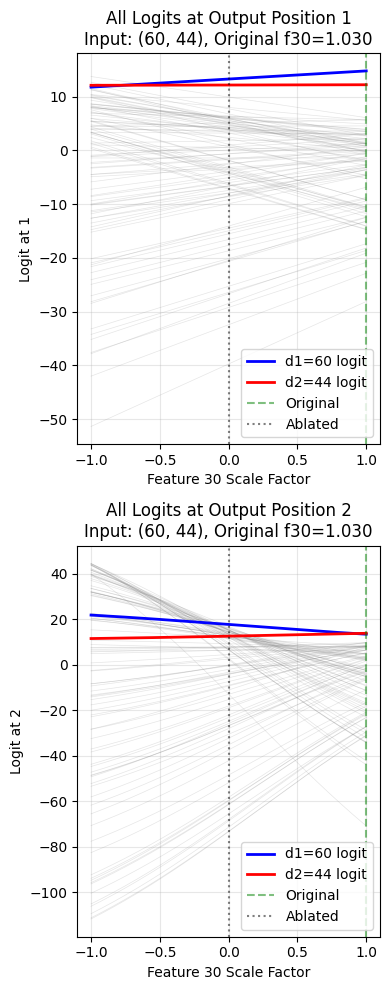


CROSSOVER ANALYSIS (exact to 3dp)

Test Case 1: Input (60, 44)
Original feature 30 activation: 1.0298
Original model output: (60, 44)

📍 O1: Found 1 crossover point(s) (linear fit)
   Crossover at scale = -0.7631 (bound=ub)
      → Model output at nearest grid: (36, 53)

📍 O2: Found 1 crossover point(s)
   Crossover #1 at scale = 0.917 (bound=ub)
      d1 logit = 13.665, d2 logit = 13.660
      → Model output: (60, 60)

--- Swap bounds ---
  No valid swap zone: no_o2_crossover_in_bounds


In [ ]:
# lets look at their graphs
# test_egs = [(55,76), (93,16), (61,26)]
test_egs = [(60,44)]

results = feature_steering_experiment(
    model, sae, act_mean,
    feature_idx=SPECIAL_FEAT_IDX,
    d1_all=d1_all, 
    d2_all=d2_all, 
    sae_acts_all=sae_acts_all, 
    dataset=all_ds,
    scale_range=[-1.0, 1.0],
    test_pairs=test_egs,
    sample_step_size=0.001
)

crossover_df = analyze_feature_crossovers(
    results=results,
    model=model, sae=sae, act_mean=act_mean,
    feature_idx=SPECIAL_FEAT_IDX,
    d1_all=d1_all, d2_all=d2_all, sae_acts_all=sae_acts_all,
    dataset=all_ds,
    layer_idx=0,
    sep_idx=SEP_TOKEN_INDEX,
    n_digits=N_DIGITS,
    device=DEVICE,
    verbose=True
)

In [ ]:
# Test the egs at different scales
for d1_val, d2_val in test_egs:
    mask = (d1_all == d1_val) & (d2_all == d2_val)
    idx = torch.where(mask)[0][0].item()
    inputs_i = all_ds[idx][0].unsqueeze(0).to(DEVICE)
    z_orig = sae_acts_all[idx].clone().to(DEVICE)
    feat_orig = z_orig[SPECIAL_FEAT_IDX].item()
    
    print(f"\n{'='*60}")
    print(f"Input: ({d1_val}, {d2_val}), Original feature {SPECIAL_FEAT_IDX}: {feat_orig:.4f}")
    print(f"{'='*60}")
    
    # Inspect at multiple scales
    custom_scales = [-0.7, -0.6, -0.5, -0.3, -0.01, 0.0]
    # custom_scales = [2.2,2.3]
    result_list, df = inspect_steered_outputs_batch(
        model=model, sae=sae, act_mean=act_mean,
        feature_idx=SPECIAL_FEAT_IDX,
        scales=custom_scales,
        inputs_i=inputs_i, z_orig=z_orig, feat_orig=feat_orig,
        d1_val=d1_val, d2_val=d2_val,
        layer_idx=0, sep_idx=SEP_TOKEN_INDEX, n_digits=N_DIGITS,
        device=DEVICE
    )
    print(df.to_string(index=False))


Input: (60, 44), Original feature 30: 1.0298
 scale  pred_o1  pred_o2  d1_logit_o1  d2_logit_o1  d1_logit_o2  d2_logit_o2
 -0.70       36       53    12.205275    12.113214    20.666218    11.719965
 -0.60       60       53    12.356327    12.118281    20.268032    11.818418
 -0.50       60       53    12.507379    12.123346    19.855534    11.921601
 -0.30       60       78    12.809483    12.133481    18.993500    12.141251
 -0.01       60       60    13.247534    12.148173    17.682379    12.486429
  0.00       60       60    13.262639    12.148680    17.636433    12.498785


 Let's focus on inputs that don't F30 can't steer (no swap bound) & see if another of the topk features activate it


Input: d1=60, d2=44  (dataset index 0)
Active SAE features (3 / 100 total):
  Feature   1: 2.9163
  Feature  56: 2.7344
  Feature  30: 1.0298

------------------------------------------------------------
Feature 1  (activation = 2.9163)
------------------------------------------------------------
Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:00<00:00,  1.83it/s]


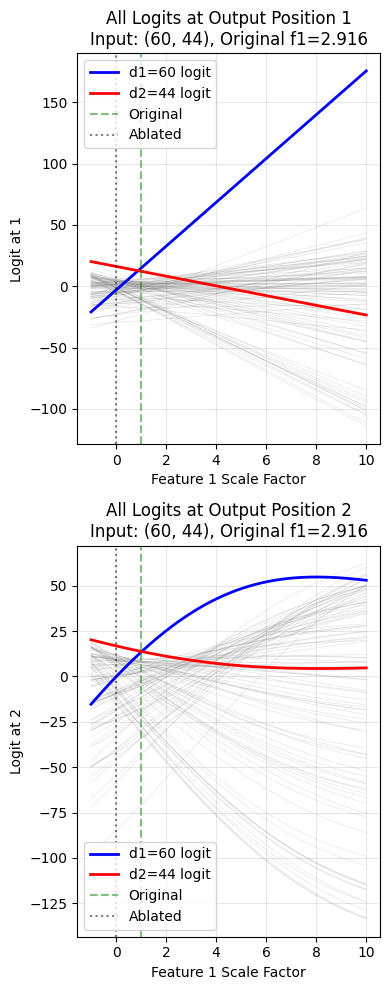


CROSSOVER ANALYSIS (exact to 3dp)

Test Case 1: Input (60, 44)
Original feature 1 activation: 2.9163
Original model output: (60, 44)

📍 O1: Found 1 crossover point(s) (linear fit)
   Crossover at scale = 0.8820 (bound=ub)
      → Model output at nearest grid: (60, 44)

📍 O2: Found 1 crossover point(s)
   Crossover #1 at scale = 1.026 (bound=lb)
      d1 logit = 13.358, d2 logit = 13.761
      → Model output: (60, 44)

--- Swap bounds ---
  No valid swap zone: no_o2_crossover_in_bounds

------------------------------------------------------------
Feature 56  (activation = 2.7344)
------------------------------------------------------------
Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:00<00:00,  1.74it/s]


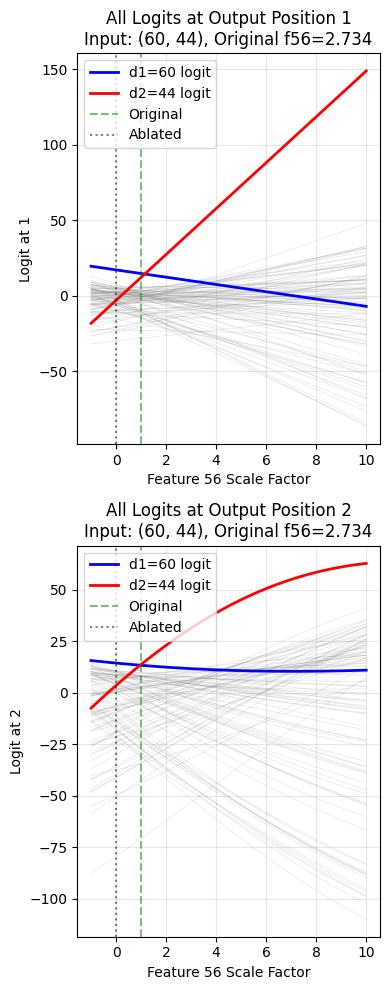


CROSSOVER ANALYSIS (exact to 3dp)

Test Case 1: Input (60, 44)
Original feature 56 activation: 2.7344
Original model output: (60, 44)

📍 O1: Found 1 crossover point(s) (linear fit)
   Crossover at scale = 1.1463 (bound=lb)
      → Model output at nearest grid: (44, 44)

📍 O2: Found 1 crossover point(s)
   Crossover #1 at scale = 0.963 (bound=ub)
      d1 logit = 13.408, d2 logit = 13.271
      → Model output: (60, 60)

--- Swap bounds ---
  No valid swap zone: no_o2_crossover_in_bounds

------------------------------------------------------------
Feature 30  (activation = 1.0298)
------------------------------------------------------------
Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s]


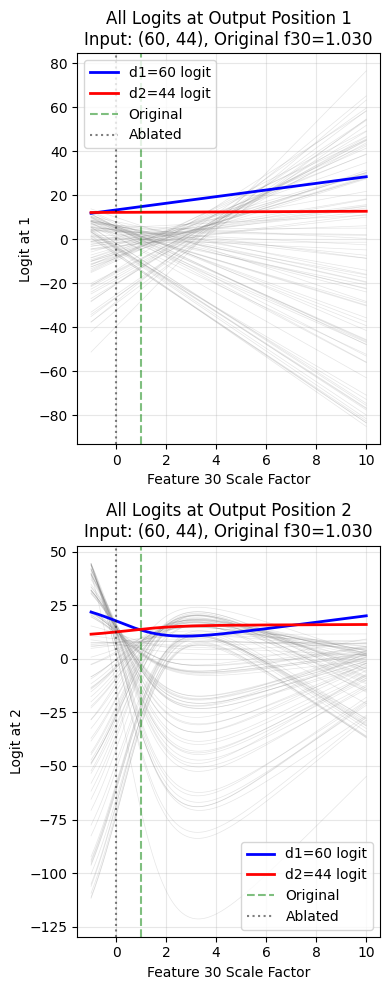


CROSSOVER ANALYSIS (exact to 3dp)

Test Case 1: Input (60, 44)
Original feature 30 activation: 1.0298
Original model output: (60, 44)

📍 O1: Found 1 crossover point(s) (linear fit)
   Crossover at scale = -0.7631 (bound=ub)
      → Model output at nearest grid: (36, 53)

📍 O2: Found 2 crossover point(s)
   Crossover #1 at scale = 0.917 (bound=ub)
      d1 logit = 13.724, d2 logit = 13.640
      → Model output: (60, 60)
   Crossover #2 at scale = 7.212 (bound=lb)
      d1 logit = 15.809, d2 logit = 15.826
      → Model output: (70, 44)

--- Swap bounds ---
  No valid swap zone: no_o2_crossover_in_bounds


In [ ]:
test_egs = [(60,44)] # (75,32) is an input that doesnt activate f30 at all


# For inputs where F30 can't steer, identify ALL active top-k features and run
# steering + crossover analysis for each one.

def analyze_topk_features_for_inputs(
    test_pairs,
    model, sae, act_mean,
    d1_all, d2_all, sae_acts_all, dataset,
    layer_idx, sep_idx, n_digits, device,
    scale_range=[-1.0, 10.0],
    sample_step_size=0.05,
):
    """
    For each (d1, d2) pair in test_pairs:
      - Print all active SAE features and their activation magnitudes
      - Run feature_steering_experiment + analyze_feature_crossovers for each active feature
    """
    for d1_val, d2_val in test_pairs:
        mask = (d1_all == d1_val) & (d2_all == d2_val)
        idx = torch.where(mask)[0][0].item()
        z_orig = sae_acts_all[idx].clone()

        # Find active features sorted by magnitude descending
        active_mask = z_orig > 0
        active_feat_indices = torch.where(active_mask)[0].tolist()
        active_feat_values = z_orig[active_mask].tolist()
        sorted_feats = sorted(zip(active_feat_indices, active_feat_values), key=lambda x: -x[1])

        print(f"\n{'='*70}")
        print(f"Input: d1={d1_val}, d2={d2_val}  (dataset index {idx})")
        print(f"Active SAE features ({len(sorted_feats)} / {z_orig.shape[0]} total):")
        for feat_idx, feat_val in sorted_feats:
            print(f"  Feature {feat_idx:>3d}: {feat_val:.4f}")

        for feat_idx, feat_val in sorted_feats:
            print(f"\n{'-'*60}")
            print(f"Feature {feat_idx}  (activation = {feat_val:.4f})")
            print(f"{'-'*60}")
            results = feature_steering_experiment(
                model, sae, act_mean,
                feature_idx=feat_idx,
                d1_all=d1_all,
                d2_all=d2_all,
                sae_acts_all=sae_acts_all,
                dataset=dataset,
                scale_range=scale_range,
                test_pairs=[(d1_val, d2_val)],
                sample_step_size=sample_step_size,
            )
            analyze_feature_crossovers(
                results=results,
                model=model, sae=sae, act_mean=act_mean,
                feature_idx=feat_idx,
                d1_all=d1_all, d2_all=d2_all, sae_acts_all=sae_acts_all,
                dataset=dataset,
                layer_idx=layer_idx,
                sep_idx=sep_idx,
                n_digits=n_digits,
                device=device,
                verbose=True,
            )

analyze_topk_features_for_inputs(
    test_pairs=test_egs,
    model=model, sae=sae, act_mean=act_mean,
    d1_all=d1_all, d2_all=d2_all, sae_acts_all=sae_acts_all,
    dataset=all_ds,
    layer_idx=0,
    sep_idx=SEP_TOKEN_INDEX,
    n_digits=N_DIGITS,
    device=DEVICE,
)

In [ ]:
test_egs = [(60,44)]
# test_egs = [(75,32)]

for d1_val, d2_val in test_egs:
    mask = (d1_all == d1_val) & (d2_all == d2_val)
    idx = torch.where(mask)[0][0].item()
    z_orig = sae_acts_all[idx].clone()

    # Find active features sorted by magnitude descending
    active_mask = z_orig > 0
    active_feat_indices = torch.where(active_mask)[0].tolist()
    active_feat_values = z_orig[active_mask].tolist()
    sorted_feats = sorted(zip(active_feat_indices, active_feat_values), key=lambda x: -x[1])

    print(f"Input: d1={d1_val}, d2={d2_val}")
    print(f"Active SAE features ({len(sorted_feats)} / {z_orig.shape[0]} total):")
    for feat_idx, feat_val in sorted_feats:
        print(f"  Feature {feat_idx:>3d}: {feat_val:.4f}")

Input: d1=60, d2=44
Active SAE features (3 / 100 total):
  Feature   1: 2.9163
  Feature  56: 2.7344
  Feature  30: 1.0298


Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:00<00:00,  1.77it/s]


  SKIP  F1 × +0.00  (orig=2.916 → 0.000)  →  o2_never_predicts_d1
Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:00<00:00,  1.84it/s]


  SKIP  F1 × +0.30  (orig=2.916 → 0.875)  →  o2_never_predicts_d1
Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:00<00:00,  1.77it/s]


  SKIP  F1 × +0.50  (orig=2.916 → 1.458)  →  o2_never_predicts_d1
Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:00<00:00,  1.80it/s]



######################################################################
  F1 × +0.70  (orig=2.916 → 2.041)
  F30 swap zone: [0.0000, 0.2500]  (midpoint=0.1250, width=0.2500)
######################################################################
Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:00<00:00,  1.82it/s]


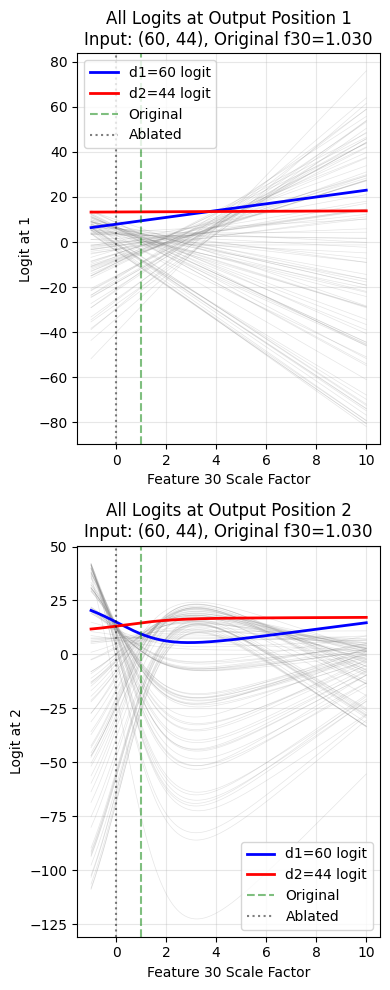


CROSSOVER ANALYSIS (exact to 3dp)

Test Case 1: Input (60, 44)
Original feature 30 activation: 1.0298
Original model output: (44, 44)

📍 O1: Found 1 crossover point(s) (linear fit)
   Crossover at scale = 3.7208 (bound=ub)
      → Model output at nearest grid: (44, 36)

📍 O2: Found 1 crossover point(s)
   Crossover #1 at scale = 0.254 (bound=ub)
      d1 logit = 13.513, d2 logit = 13.480
      → Model output: (44, 60) SWAPPED!

--- Swap bounds ---
  Scale range: [0.0000, 0.2500]
  Midpoint: 0.1250,  Width: 0.2500
Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:00<00:00,  1.54it/s]


  SKIP  F1 × +1.00  (orig=2.916 → 2.916)  →  no_o2_crossover_in_bounds
Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:00<00:00,  1.49it/s]


  SKIP  F56 × +0.00  (orig=2.734 → 0.000)  →  no_o2_crossover
Using 1 specified input pairs


...

  SKIP  F56 × +0.50  (orig=2.734 → 1.367)  →  no_o2_crossover
Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:00<00:00,  1.82it/s]


  SKIP  F56 × +0.70  (orig=2.734 → 1.914)  →  no_o2_crossover
Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:00<00:00,  1.84it/s]


  SKIP  F56 × +1.00  (orig=2.734 → 2.734)  →  no_o2_crossover_in_bounds


SUMMARY  |  F30 crossovers for (60,44) under pre-scaled F1 / F56
                        condition f30_orig_act                       swap_zone o1_crossovers o1_fail  o2_crossovers
 F1 × +0.00  (orig=2.916 → 0.000)       1.0298      FAIL: o2_never_predicts_d1      [14.183]      ok       [-0.590]
 F1 × +0.30  (orig=2.916 → 0.875)       1.0298      FAIL: o2_never_predicts_d1       [9.699]      ok       [-0.286]
 F1 × +0.50  (orig=2.916 → 1.458)       1.0298      FAIL: o2_never_predicts_d1       [6.710]      ok       [-0.043]
 F1 × +0.70  (orig=2.916 → 2.041)       1.0298                [0.0000, 0.2500]       [3.721]      ok        [0.254]
 F1 × +1.00  (orig=2.916 → 2.916)       1.0298 FAIL: no_o2_crossover_in_bounds      [-0.763]      ok [0.917, 7.212]
F56 × +0.00  (orig=2.734 → 0.000)       1.0298           FAIL: no_o2_crossover     [-12.816]      ok             []
F56 × +0.30  (orig=2.734 → 0.820)       1.0298   

In [ ]:
# okay so f1, f56 and f30 are all active for 60,44 input.
# Run the F30 steering experiment while pre-fixing F1 / F56 to different scale values.
# For each (side_feat, side_scale), we clone sae_acts_all, set that feature to
# orig_val * side_scale at the (60,44) sample index, then run the F30 steering
# experiment + crossover analysis from that modified baseline.
SPECIAL_FEAT_IDX = 30
other_scales = {
    1: [0.0, 0.3, 0.5, 0.7, 1.0],
    # 65: np.linspace(0.0, 10.0, 200).tolist(),
    56: [0.0, 0.3, 0.5, 0.7, 1.0],
}

d1_val, d2_val = test_egs[0]
mask = (d1_all == d1_val) & (d2_all == d2_val)
idx_eg = torch.where(mask)[0][0].item()
z_base = sae_acts_all[idx_eg].clone()

summary_rows = []

SCALE_RANGE = [-1.0, 10.0]
STEP_SIZE   = 0.05

for side_feat, side_scales in other_scales.items():
    orig_side_val = z_base[side_feat].item()

    for side_scale in side_scales:
        new_side_val = orig_side_val * side_scale
        label = f"F{side_feat} × {side_scale:+.2f}  (orig={orig_side_val:.3f} → {new_side_val:.3f})"

        # Build modified activations with side feature pre-scaled at this sample
        sae_acts_mod = sae_acts_all.clone()
        sae_acts_mod[idx_eg, side_feat] = new_side_val

        # ── First pass: silent, just to check whether a valid swap zone exists ──
        results_silent = feature_steering_experiment(
            model, sae, act_mean,
            feature_idx=SPECIAL_FEAT_IDX,
            d1_all=d1_all, d2_all=d2_all, sae_acts_all=sae_acts_mod,
            dataset=all_ds,
            scale_range=SCALE_RANGE,
            test_pairs=[(d1_val, d2_val)],
            sample_step_size=STEP_SIZE,
            plot=False,
        )
        crossover_df_silent = analyze_feature_crossovers(
            results=results_silent,
            model=model, sae=sae, act_mean=act_mean,
            feature_idx=SPECIAL_FEAT_IDX,
            d1_all=d1_all, d2_all=d2_all, sae_acts_all=sae_acts_mod,
            dataset=all_ds,
            layer_idx=0, sep_idx=SEP_TOKEN_INDEX, n_digits=N_DIGITS,
            device=DEVICE, verbose=False,
        )

        # Build swap-bounds row (needs scales + argmax sequences from results)
        cr = crossover_df_silent.iloc[0]
        swap_check_row = {
            **cr.to_dict(),
            'scales':    list(results_silent[0]['scales']),
            'argmax_o1': list(results_silent[0]['output_o1']),
            'argmax_o2': list(results_silent[0]['output_o2']),
        }
        bounds = get_output_swap_bounds(pd.DataFrame([swap_check_row]), scale_range=SCALE_RANGE)
        b = bounds.iloc[0]
        has_valid_swap = pd.isna(b['failure_reason'])

        # Accumulate summary
        row_dict = cr.to_dict()
        row_dict.update({
            'side_feat':    side_feat,
            'side_scale':   side_scale,
            'side_orig_val': orig_side_val,
            'side_new_val':  new_side_val,
            'label':         label,
            'swap_lower':    b['lower_bound'],
            'swap_upper':    b['upper_bound'],
            'swap_failure':  b['failure_reason'],
        })
        summary_rows.append(row_dict)

        if not has_valid_swap:
            print(f"  SKIP  {label}  →  {b['failure_reason']}")
            continue

        # ── Valid swap zone — show full results ──────────────────────────────
        print(f"\n{'#'*70}")
        print(f"  {label}")
        print(f"  F30 swap zone: [{b['lower_bound']:.4f}, {b['upper_bound']:.4f}]  "
              f"(midpoint={b['midpoint']:.4f}, width={b['swap_zone_width']:.4f})")
        print(f"{'#'*70}")

        # Re-run with plot=True and verbose crossover output
        results_full = feature_steering_experiment(
            model, sae, act_mean,
            feature_idx=SPECIAL_FEAT_IDX,
            d1_all=d1_all, d2_all=d2_all, sae_acts_all=sae_acts_mod,
            dataset=all_ds,
            scale_range=SCALE_RANGE,
            test_pairs=[(d1_val, d2_val)],
            sample_step_size=STEP_SIZE,
            plot=True,
        )
        analyze_feature_crossovers(
            results=results_full,
            model=model, sae=sae, act_mean=act_mean,
            feature_idx=SPECIAL_FEAT_IDX,
            d1_all=d1_all, d2_all=d2_all, sae_acts_all=sae_acts_mod,
            dataset=all_ds,
            layer_idx=0, sep_idx=SEP_TOKEN_INDEX, n_digits=N_DIGITS,
            device=DEVICE, verbose=True,
        )

# ── Comparison summary table ──────────────────────────────────────────────────
print(f"\n\n{'='*80}")
print(f"SUMMARY  |  F30 crossovers for ({d1_val},{d2_val}) under pre-scaled F1 / F56")
print(f"{'='*80}")

summary_df = pd.DataFrame(summary_rows)

# Format list columns for readability
def _fmt_xovers(val):
    if isinstance(val, list) and val:
        return "[" + ", ".join(f"{x:.3f}" for x in val) + "]"
    return "[]"

display_df = pd.DataFrame({
    'condition':      summary_df['label'],
    'f30_orig_act':   summary_df['feat_orig'].map(lambda x: f"{x:.4f}"),
    'swap_zone':      summary_df.apply(
                          lambda r: (f"[{r['swap_lower']:.4f}, {r['swap_upper']:.4f}]"
                                     if pd.isna(r['swap_failure']) else f"FAIL: {r['swap_failure']}"),
                          axis=1),
    'o1_crossovers':  summary_df['o1_crossovers'].map(_fmt_xovers),
    'o1_fail':        summary_df['o1_failure_reason'].fillna('ok'),
    'o2_crossovers':  summary_df['o2_crossovers'].map(_fmt_xovers),
})

print(display_df.to_string(index=False))

 running on (60,44) input we have f1, f56, f30 active. Pre-scaling f1 by 0.70x
 and doing feature steering on f30 as normal gives us a swap zone [0, 0.25]
 ==> maybe this is possible for other inputs that f30 fails to swap on its own!
 but why? its because the other features also affect the logits and this scale means that the swap zone
 which was previously hidden (no overlap between o1 and o2 crossovers where d1 and d2 are argmax where needed)
 is suddenly open

 runnong on (75,32) input we have f86, f65 (Feature  65: 3.5795, Feature  86: 2.1088))
 I tried loads of combos (200 scales between 0 and 10 for f86, and 200 scales between 0 and 10 for f65) but no swap zone appears.

 The model gets both of these inputs correct originally. Perhaps they just don't fit into the pattern that others do